# Cross-modal integration: Cell Painting morphology vs. scRNA-seq

In previous approach, we performed a broad structure-level correlation using Mantel Analysis after PCA reduction and averaging at the level of drug groups. Now we want to test if preserving the variation pre-averaging can lead to better correlations. More specifically, we want to compare DISTRIBUTIONS of drugs in morphology and RNA space (in contrast to our previous appraoch where each drug was a single point compared by Euclidean distance, we now represent them as clouds and use Wasserstein distances)

In [2]:
import glob
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import ot                          # pip install POT
from scipy.stats import pearsonr
import seaborn as sns

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 30

PALETTE = [
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
    "#008300", "#4a3aa7", "#e34948", "#6b4226", "#38a5b0",
    "#a24fbf", "#c2914e", "#5a6bd6", "#c65da0", "#6f9e1f",
    "#d65f5f", "#3f7d8c", "#9a7dcb", "#b25b2a", "#4f9d6e",
    "#8c8c8c",
]


## 1. Load gene expression


In [3]:
rna = ad.read_h5ad("./data/hepg2_cells.h5ad")
rna.var_names = rna.var["gene_symbol"].astype(str)
rna.var_names_make_unique()

print(f"{rna.n_obs} cells x {rna.n_vars} genes")
print(f"{rna.obs['drug'].nunique()} drugs, {rna.obs['plate'].nunique()} plates, "
      f"{rna.obs['moa-fine'].nunique()} moa-fine classes, cell line {rna.obs['cell_line_id'].unique().tolist()}")

drug_summary = (
    rna.obs.groupby("drug", observed=True)
    .agg(n_cells=("drug", "size"), moa_fine=("moa-fine", "first"))
    .sort_values("n_cells")
)
drug_summary.head()


389085 cells x 62710 genes
120 drugs, 14 plates, 21 moa-fine classes, cell line ['CVCL_1098']


,n_cells,moa_fine
drug,,
Menadione,925,unclear
Clofarabine,1006,DNA synthesis/repair inhibitor
Pemetrexed,1015,DNA synthesis/repair inhibitor
Canagliflozin,1079,Glucose transporter inhibitor
Silodosin,1110,unclear


## 2. Match compounds between datasets

In [4]:
ANNOTATION_DIR = "../annotations"

compounds = pd.read_csv(os.path.join(ANNOTATION_DIR, "pd_export_04_2022_2464_compounds_standardized.csv"))
compounds = compounds.drop_duplicates(subset="name", keep="first")
name_to_pdid = dict(zip(compounds["name"].str.lower().str.strip(), compounds["pdid"]))

synonym_to_pdid = {}
for _, row in compounds.iterrows():
    for syn in str(row["synonyms"] or "").split(";"):
        syn = syn.strip().lower()
        if syn:
            synonym_to_pdid.setdefault(syn, row["pdid"])

# Common salt/hydrate/counter-ion suffixes that show up as a bare trailing
# word rather than inside parentheses (e.g. "Larotrectinib sulfate",
# "Ralimetinib dimesylate") - stripped repeatedly in case more than one is
# stacked (e.g. "... dihydrochloride hydrate").
SALT_SUFFIX_RE = re.compile(
    r"\s+(?:hydrochlorides?|dihydrochloride|trihydrochloride|sulfates?|disulfate|"
    r"bisulfate|mesylate|dimesylate|tosylate|besylate|maleate|fumarate|"
    r"citrate|acetate|phosphate|diphosphate|hydrobromide|dihydrobromide|"
    r"succinate|oxalate|nitrate|lactate|malate|gluconate|tartrate|bitartrate|"
    r"hemihydrate|monohydrate|dihydrate|trihydrate|tetrahydrate|hydrate|"
    r"sodium|potassium|calcium|iodide|bromide|chloride|palmitate|stearate|"
    r"benzoate|carbonate|bicarbonate|pamoate|isethionate|napadisylate|"
    r"edisylate)\s*$",
    re.IGNORECASE,
)


def strip_formulation_suffix(name: str) -> str:
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name).strip()
    prev = None
    while prev != name:
        prev = name
        name = SALT_SUFFIX_RE.sub("", name).strip()
    return name


def match_drug_to_pdid(drug: str) -> str | None:
    key = drug.lower().strip()
    for candidate in (key, strip_formulation_suffix(key)):
        if candidate in name_to_pdid:
            return name_to_pdid[candidate]
        if candidate in synonym_to_pdid:
            return synonym_to_pdid[candidate]
    return None


drug_to_pdid = {d: match_drug_to_pdid(d) for d in rna.obs["drug"].cat.categories}
n_matched = sum(v is not None for v in drug_to_pdid.values())
print(f"Matched {n_matched}/{len(drug_to_pdid)} drugs to the morphology compound reference")
print("Unmatched:", [d for d, p in drug_to_pdid.items() if p is None])

Matched 120/120 drugs to the morphology compound reference
Unmatched: []


## 3. Gene expression: standard transformations


In [5]:
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=N_PCS, mask_var="highly_variable", random_state=RANDOM_STATE)

rna_pcs = pd.DataFrame(rna.obsm["X_pca"], index=rna.obs_names)
rna_pcs["drug"] = rna.obs["drug"].to_numpy()

#rna_compound_pca = rna_pcs.groupby("drug", observed=True).mean()

moa_by_drug = rna.obs.groupby("drug", observed=True)["moa-fine"].first()

print(f"Per-drug expression embedding: {rna_pcs.shape}")
rna_pcs.head()


Per-drug expression embedding: (389085, 31)


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,drug
0,-1.419116,-3.842204,0.895473,0.739501,-1.253178,-0.609106,0.611995,-0.681506,-0.903672,-0.423149,...,0.978718,-0.131487,-1.249332,-0.397210,-1.508193,0.274103,-1.139027,-0.329153,-1.448031,8-Hydroxyquinoline
1,0.858095,-0.681276,-1.324257,-2.331487,-0.491992,-0.737514,-2.206337,-0.890149,-2.436814,0.430591,...,-0.977132,-0.237734,0.232421,-0.165710,-0.104579,0.625021,-0.251628,-0.827957,0.372529,8-Hydroxyquinoline
2,-1.648808,-1.297427,2.640908,-2.529994,-0.312628,0.130808,-0.100061,0.975362,-1.536296,-0.156860,...,1.025835,1.156089,0.320495,0.532941,-0.175869,-0.454655,-0.104319,0.459318,-0.935416,8-Hydroxyquinoline
3,3.496257,1.839901,2.378817,-1.138224,0.202866,0.308559,-0.713041,-1.132313,-0.314162,-0.517778,...,-0.546667,1.012768,-1.638791,0.486728,0.243359,0.265524,-0.076969,0.256208,0.778175,Retinoic acid
4,2.499368,-0.964662,-0.465002,0.663570,-0.683248,-3.427688,0.015983,0.038926,-0.533079,0.546163,...,-1.108450,-0.243963,0.516356,0.745481,1.944171,1.066313,-0.130474,-0.276138,0.548913,Retinoic acid


In [6]:
rna_pcs["drug"].nunique()

120

## 4. Morphology: well-level PCA over pooled HepG2 sites


In [7]:
DATA_DIR = "../aggregated_data"
HEPG2_SITES = [d for d in sorted(os.listdir(DATA_DIR)) if d.endswith("HepG2")]
COMPARTMENTS = ["Cells", "Nuc", "Cyto"]

PLATE_RE = re.compile(r"B\d{3,}")
REPLICATE_RE = re.compile(r"(?<![A-Za-z])R\d+")


def parse_plate_replicate(filename: str) -> tuple[str, str]:
    return PLATE_RE.search(filename).group(), REPLICATE_RE.search(filename).group()


def load_site_profiles(site_dir: str, site_name: str) -> pd.DataFrame:
    frames = []
    for f in sorted(glob.glob(os.path.join(site_dir, "*.csv"))):
        d = pd.read_csv(f)
        feature_cols = [c for c in d.columns if not c.startswith("Metadata_")]
        d[feature_cols] = d[feature_cols].astype("float32")
        plate, replicate = parse_plate_replicate(os.path.basename(f))
        d["Metadata_Site"] = site_name
        d["Metadata_PlateID"] = plate
        d["Metadata_Replicate"] = replicate
        d["Metadata_SourceFile"] = f"{site_name}_{plate}_{replicate}"
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


def normalize_per_plate(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    parts = [
        normalize(
            group, features=features, meta_features="infer",
            samples="all", method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


print(f"HepG2 sites: {HEPG2_SITES}")
hepg2_raw = {site: load_site_profiles(os.path.join(DATA_DIR, site), site) for site in HEPG2_SITES}

FEATURES = infer_cp_features(next(iter(hepg2_raw.values())), compartments=COMPARTMENTS)
hepg2_normalized = {site: normalize_per_plate(df, FEATURES) for site, df in hepg2_raw.items()}
hepg2_pooled = pd.concat(hepg2_normalized.values(), ignore_index=True)
print(f"{len(hepg2_pooled)} wells pooled across {len(HEPG2_SITES)} HepG2 sites, {len(FEATURES)} inferred features")


HepG2 sites: ['FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']
42847 wells pooled across 4 HepG2 sites, 2977 inferred features


In [8]:
FEATURE_SELECT_OPS = [
    "variance_threshold", "frequency_threshold", "correlation_threshold",
    "drop_na_columns", "blocklist", "drop_outliers",
]
hepg2_selected = feature_select(hepg2_pooled, features=FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in hepg2_selected.columns if not c.startswith("Metadata_")]
print(f"{len(morph_feature_cols)} features selected on pooled HepG2 data")

SITE_ANNOTATION_FILES = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv", 
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}
eos_to_pdid = pd.read_csv(os.path.join(ANNOTATION_DIR, "2024-08-02_EOS_pdid.csv"))
eos_to_pdid_map = dict(zip(eos_to_pdid["Metadata_EOS"], eos_to_pdid["Metadata_pdid"]))


def load_well_pdid(site: str) -> pd.DataFrame:
    ann = pd.read_csv(os.path.join(ANNOTATION_DIR, SITE_ANNOTATION_FILES[site]))
    ann = ann.rename(columns={"Metadata_Plate": "Metadata_PlateID", "Metadata_Batch": "Metadata_Replicate"})
    ann["Metadata_pdid"] = ann["Metadata_EOS"].map(eos_to_pdid_map)
    ann["Metadata_negcon"] = ann["Metadata_EOS"] == "DMSO"
    return ann[["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate", "Metadata_pdid", "Metadata_negcon"]]


hepg2_selected = pd.concat(
    [
        group.merge(load_well_pdid(site), on=["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate"], how="left")
        for site, group in hepg2_selected.groupby("Metadata_Site")
    ],
    ignore_index=True,
)
print(f"{hepg2_selected['Metadata_pdid'].notna().mean():.1%} of HepG2 wells resolved to a pdid")


636 features selected on pooled HepG2 data
91.6% of HepG2 wells resolved to a pdid


In [9]:
morph_adata = ad.AnnData(
    X=hepg2_selected[morph_feature_cols].to_numpy(dtype=np.float32),
    obs=hepg2_selected[["Metadata_Site", "Metadata_pdid"]].reset_index(drop=True),
)
n_pcs_morph = min(N_PCS, morph_adata.n_vars - 1, morph_adata.n_obs - 1)
sc.pp.pca(morph_adata, n_comps=n_pcs_morph, random_state=RANDOM_STATE)

pdid_to_drug = {pdid: drug for drug, pdid in drug_to_pdid.items() if pdid is not None}

morph_pcs = pd.DataFrame(morph_adata.obsm["X_pca"], index=morph_adata.obs_names)
morph_pcs["drug"] = morph_adata.obs["Metadata_pdid"].map(pdid_to_drug).to_numpy()

#morph_compound_pca = morph_pcs.dropna(subset=["drug"]).groupby("drug").mean()

print(f"Per-compound morphology embedding: {morph_pcs.shape}")
morph_pcs.head()


Per-compound morphology embedding: (42847, 31)


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,drug
0,-14.765734,43.634525,33.760059,-6.936990,-1.358765,1.770779,6.180900,-7.956247,12.980008,-2.529766,...,13.413112,0.583776,-13.306288,-11.908064,-2.140949,-1.083075,8.299356,-1.305877,-1.267381,NaN
1,-15.463007,-5.765176,1.001246,4.800321,-1.847430,1.251067,2.924676,-2.663030,3.165957,2.530773,...,-0.268889,-1.010934,-0.787333,-2.187164,2.853067,-3.356681,-0.817465,3.665663,-1.721744,NaN
2,-10.060709,5.763758,4.152132,6.218499,-3.645664,-3.745259,0.731860,4.055068,-2.808321,4.640962,...,3.772347,0.352786,5.360732,-6.823301,4.158139,-2.526537,4.176167,-0.946433,-3.542346,NaN
3,-8.552681,-5.592972,-1.919995,2.755208,-1.081030,-2.685682,-4.778774,-6.882562,-0.699666,-0.363233,...,-0.773908,-4.416111,-0.901075,-1.530129,0.451567,-0.738641,-0.621753,-0.305234,-3.100349,NaN
4,112.323914,76.876999,-23.548819,-41.826340,36.811539,19.452034,9.573679,-8.934531,32.811092,-26.066715,...,-0.526531,-10.878553,12.188896,4.583501,23.703856,-5.256679,2.835119,12.102465,6.378668,Amsacrine


In [10]:
print(morph_pcs["drug"].isna().sum())

print(pdid_to_drug)

print(morph_adata.obs["Metadata_pdid"].nunique())

print(morph_pcs.head(n=20))

40957
{'PD002327': '5-Fluorouracil', 'PD011920': '8-Hydroxyquinoline', 'PD014316': '18β-Glycyrrhetinic acid', 'PD004706': 'AT7519', 'PD010380': 'AZD2858', 'PD003359': 'AZD-8055', 'PD012199': 'Abiraterone acetate', 'PD000420': 'Acetohexamide', 'PD009402': 'Aliskiren', 'PD003422': 'Alpelisib', 'PD001093': 'Altretamine', 'PD001019': 'Amsacrine', 'PD009855': 'Aprepitant', 'PD012898': 'Belumosudil', 'PD003516': 'Bendamustine', 'PD001569': 'Bergenin', 'PD003617': 'Bexarotene', 'PD010655': 'Binimetinib', 'PD003632': 'Bortezomib', 'PD009964': 'Bosentan (hydrate)', 'PD002794': 'Brivudine', 'PD002795': 'Budesonide', 'PD000132': 'Canagliflozin', 'PD010264': 'Capivasertib', 'PD012871': 'Capmatinib', 'PD001635': 'Captopril', 'PD000893': 'Celecoxib', 'PD003531': 'Ciclopirox', 'PD000554': 'Cilostazol', 'PD003199': 'Clobetasol propionate', 'PD003455': 'Clofarabine', 'PD002411': 'Clotrimazole', 'PD003542': 'Dabrafenib', 'PD008540': 'Daidzin', 'PD000129': 'Dapagliflozin', 'PD009517': 'Digitoxin', 'PD009

A lot of wells out the 40k do not correspond to our compounds of interest ! These wells have 2464 unique chemical IDs, while we use only 119 of them. Out of 42847, 40957 do not correspond to our compounds. This averages to about 15 wells per drug (across sites). Check if its uniform across drugs 

count    119.000000
mean      15.882353
std        0.884676
min        7.000000
25%       16.000000
50%       16.000000
75%       16.000000
max       16.000000
dtype: float64

Compounds with < 5 wells:  0
Compounds with < 10 wells: 1
Compounds with >= 10 wells: 118


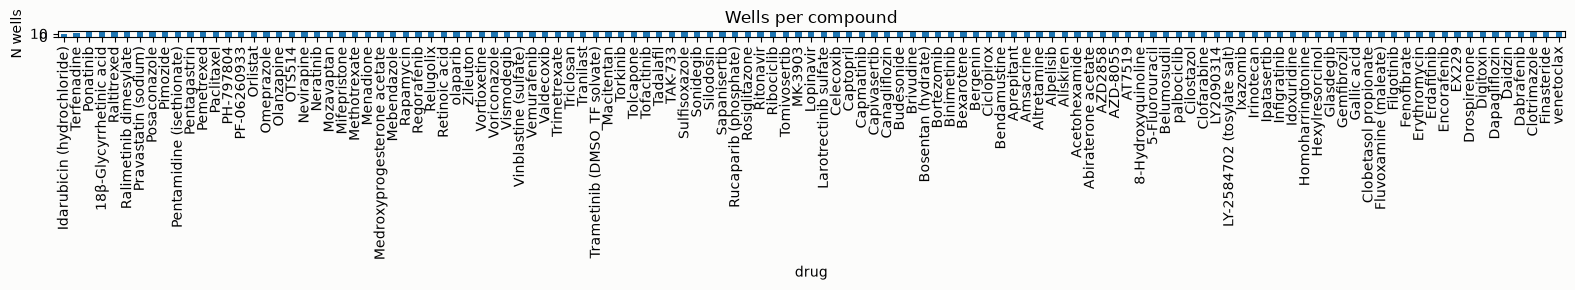

In [11]:
wells_per_compound = (
    morph_pcs[morph_pcs["drug"].notna()]
    .groupby("drug")
    .size()
    .sort_values()
)
print(wells_per_compound.describe())
print(f"\nCompounds with < 5 wells:  {(wells_per_compound < 5).sum()}")
print(f"Compounds with < 10 wells: {(wells_per_compound < 10).sum()}")
print(f"Compounds with >= 10 wells: {(wells_per_compound >= 10).sum()}")

# Visualise the imbalance
import matplotlib.pyplot as plt
wells_per_compound.plot(kind="bar", figsize=(16, 3))
plt.ylabel("N wells")
plt.title("Wells per compound")
plt.tight_layout()
plt.show()

Most compounds have 16 replicates, except one compound that has only 7. Should be still sufficient for Optimal Transport. Drop the NAs wells

In [12]:
morph_clean_pcs = morph_pcs.dropna(subset=["drug"]).reset_index(drop=True)

morph_clean_pcs.shape

(1890, 31)

In [13]:
print(morph_clean_pcs)

print(morph_clean_pcs["drug"].nunique())

### we have 119 unique compounds in morphology data while 120 in RNAseq data. Keep the same drugs

common_drugs = sorted(set(morph_clean_pcs["drug"]) & set(rna_pcs["drug"]))
morph_clean_pcs = morph_clean_pcs[morph_clean_pcs["drug"].isin(common_drugs)]
rna_pcs = rna_pcs[rna_pcs["drug"].isin(common_drugs)]
print(f"Common drugs: {len(common_drugs)}, dropped from RNA: {set(rna_pcs['drug']) - set(common_drugs)}")

               0          1          2          3          4          5  \
0     112.323914  76.876999 -23.548819 -41.826340  36.811539  19.452034   
1      11.786042  -0.926035   5.445455  -4.007427  11.095429   2.816558   
2     -11.549606  -1.929727   5.158578  -0.203571   2.337299   5.460636   
3     170.026718  27.646471 -29.066071  -0.740020  79.597954  10.792651   
4      -3.311238  -1.404240  -0.310133  -0.543919   3.216267   2.885159   
...          ...        ...        ...        ...        ...        ...   
1885   46.272858  11.191366 -48.751865  46.388355 -37.009155  -9.973405   
1886  -11.212763  11.473549   4.462780   6.172060 -11.900908  -7.320677   
1887  -17.297949   3.431709   3.119211   6.771932  -6.897718   4.830384   
1888  -10.312858   4.631949  -0.481960  -3.712834  -6.103059  -4.212466   
1889  -14.867803   6.499663   3.727824   3.288982 -12.934414  -4.579597   

              6          7          8          9  ...        21         22  \
0      9.573679  -8.9

## 5. Cross-modal agreement

Use OT to learn a mapping between the distributions in RNA and morphology space 


In [15]:
# Scale PCA coords before Wasserstein — critical, SWD is not scale-invariant
rna_pca_scaled = StandardScaler().fit_transform(rna_pcs[rna_pcs.columns.difference(["drug"])].values)

rna_distrs = {}
rna_distrs = {
    drug: rna_pca_scaled[rna_pcs["drug"].values == drug]
    for drug in common_drugs
}       # shape: n_cells_for_drug x 30
    
# Quick sanity: cells per drug
cells_per_drug = pd.Series({d: len(v) for d, v in rna_distrs.items()})
print(cells_per_drug.describe())


count     119.000000
mean     3231.369748
std      1672.495273
min       925.000000
25%      1888.000000
50%      2735.000000
75%      4587.500000
max      8171.000000
dtype: float64


In [16]:
## Now for morphology 

morph_pca_scaled = StandardScaler().fit_transform(
    morph_clean_pcs[morph_clean_pcs.columns.difference(["drug"])].values
)

morph_distrs = {
    drug: morph_pca_scaled[morph_clean_pcs["drug"].values == drug]
    for drug in common_drugs
}

wells_per_drug = pd.Series({d: len(v) for d, v in morph_distrs.items()})
print(wells_per_drug.describe())

count    119.000000
mean      15.882353
std        0.884676
min        7.000000
25%       16.000000
50%       16.000000
75%       16.000000
max       16.000000
dtype: float64


Calculate pairwise Sliced Wasserstein distance (1D approx - computationally more efficient) matrices within each modality (there is no cross modality mapping)

In [17]:
def pairwise_sliced_wasserstein(distrs, drugs, n_projections=200, seed=0):
    n = len(drugs)
    D = np.zeros((n, n))
    total = n * (n - 1) // 2
    done = 0
    
    for i in range(n):
        for j in range(i + 1, n):
            d = ot.sliced_wasserstein_distance(
                distrs[drugs[i]],
                distrs[drugs[j]],
                n_projections=n_projections,
                seed=seed,
            )
            D[i, j] = D[j, i] = d
            done += 1
            if done % 500 == 0:
                print(f"  {done}/{total} pairs done")
    return D

W_rna  = pairwise_sliced_wasserstein(rna_distrs, common_drugs, n_projections=200)

W_morph = pairwise_sliced_wasserstein(morph_distrs, common_drugs, n_projections=200)

  500/7021 pairs done
  1000/7021 pairs done
  1500/7021 pairs done
  2000/7021 pairs done
  2500/7021 pairs done
  3000/7021 pairs done
  3500/7021 pairs done
  4000/7021 pairs done
  4500/7021 pairs done
  5000/7021 pairs done
  5500/7021 pairs done
  6000/7021 pairs done
  6500/7021 pairs done
  7000/7021 pairs done
  500/7021 pairs done
  1000/7021 pairs done
  1500/7021 pairs done
  2000/7021 pairs done
  2500/7021 pairs done
  3000/7021 pairs done
  3500/7021 pairs done
  4000/7021 pairs done
  4500/7021 pairs done
  5000/7021 pairs done
  5500/7021 pairs done
  6000/7021 pairs done
  6500/7021 pairs done
  7000/7021 pairs done


In [19]:
import pickle 

with open("W_rna_results.pkl", "wb") as f:
    pickle.dump(W_rna, f)

with open("W_morph_results.pkl", "wb") as f:
    pickle.dump(W_morph, f)

In [18]:
def mantel_test(D1, D2, n_permutations=999, seed=0):
    """Permutes rows/cols of D1 (drug labels) to build null."""
    rng = np.random.default_rng(seed)
    n = D1.shape[0]
    idx = np.triu_indices(n, k=1)
    v1, v2 = D1[idx], D2[idx]
    
    r_obs = pearsonr(v1, v2)[0]
    
    r_perm = np.empty(n_permutations)
    for k in range(n_permutations):
        perm = rng.permutation(n)
        D1_perm = D1[np.ix_(perm, perm)]
        r_perm[k] = pearsonr(D1_perm[idx], v2)[0]
    
    p_val = np.mean(r_perm >= r_obs)
    return r_obs, p_val, r_perm

r_obs, p_val, r_perm = mantel_test(W_rna, W_morph)
print(f"\nWasserstein Mantel r = {r_obs:.4f},  p = {p_val:.4f}")
print(f"Previous mean-based Mantel r = 0.334")
print(f"Delta r = {r_obs - 0.334:+.4f}")


Wasserstein Mantel r = 0.3094,  p = 0.0080
Previous mean-based Mantel r = 0.334
Delta r = -0.0246


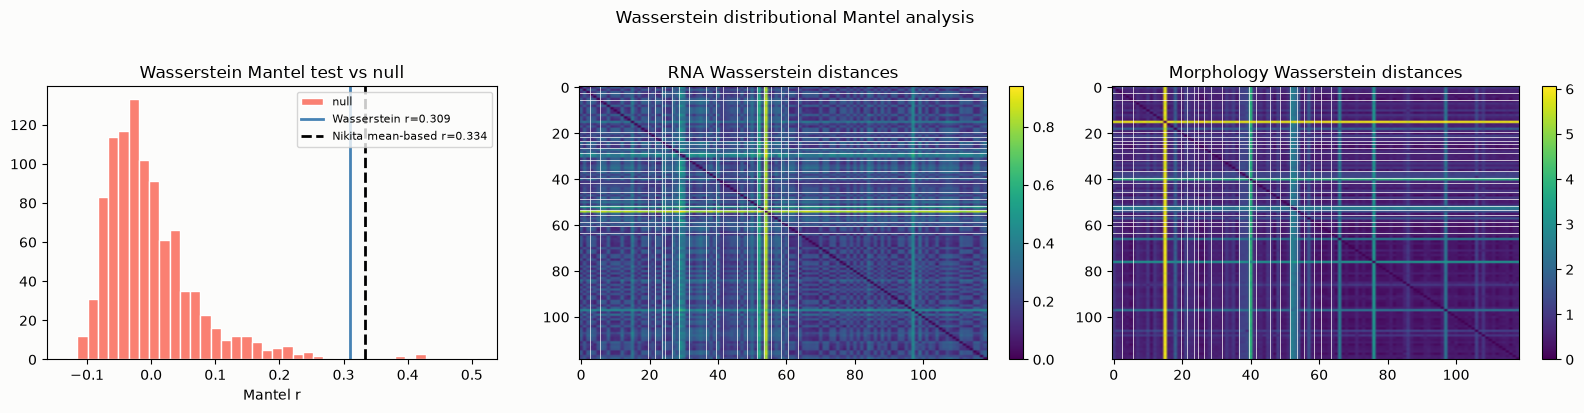

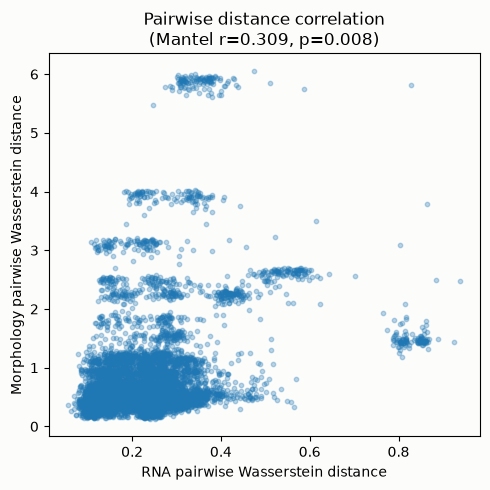

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Null distribution with observed r ────────────────────────────────────────
axes[0].hist(r_perm, bins=40, color="salmon", edgecolor="white", label="null")
axes[0].axvline(r_obs,  color="steelblue", lw=2, label=f"Wasserstein r={r_obs:.3f}")
axes[0].axvline(0.334,  color="black",     lw=2, linestyle="--", label="Nikita mean-based r=0.334")
axes[0].set_xlabel("Mantel r")
axes[0].set_title("Wasserstein Mantel test vs null")
axes[0].legend(fontsize=8)

# ── Distance matrix heatmaps side by side ────────────────────────────────────
# Reorder drugs by MoA for interpretability
drug_moa = (
    pd.DataFrame({"drug": common_drugs})
    .merge(moa_by_drug, on="drug")
    .sort_values("moa-fine")
)
order_idx = drug_moa.index.tolist()
ordered_drugs = drug_moa["drug"].tolist()

for ax, D, title in zip(
    axes[1:],
    [W_rna[np.ix_(order_idx, order_idx)],
     W_morph[np.ix_(order_idx, order_idx)]],
    ["RNA Wasserstein distances", "Morphology Wasserstein distances"],
):
    im = ax.imshow(D, aspect="auto", cmap="viridis")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Add MoA block boundaries
    moa_sizes = drug_moa.groupby("moa-fine", sort=False).size().cumsum().values
    for boundary in moa_sizes[:-1]:
        ax.axhline(boundary - 0.5, color="white", lw=0.5)
        ax.axvline(boundary - 0.5, color="white", lw=0.5)

plt.suptitle("Wasserstein distributional Mantel analysis", y=1.02)
plt.tight_layout()
plt.savefig("wasserstein_mantel.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Scatter of upper triangle distances: do they agree? ──────────────────────
idx = np.triu_indices(len(common_drugs), k=1)
fig4, ax4 = plt.subplots(figsize=(5, 5))
ax4.scatter(W_rna[idx], W_morph[idx], alpha=0.3, s=10)
ax4.set_xlabel("RNA pairwise Wasserstein distance")
ax4.set_ylabel("Morphology pairwise Wasserstein distance")
ax4.set_title(f"Pairwise distance correlation\n(Mantel r={r_obs:.3f}, p={p_val:.3f})")
plt.tight_layout()
plt.show()

We can see weird patches. Is this related to morphology? Could it be a site-specific batch effect ? Try site specific mean normalization to see if it improves 

In [23]:
## Reprocess again but this time keeping the metadata site 

morph_pcs_v2 = pd.DataFrame(morph_adata.obsm["X_pca"], index=morph_adata.obs_names)
morph_pcs_v2["drug"] = morph_adata.obs["Metadata_pdid"].map(pdid_to_drug).to_numpy()
morph_pcs_v2["Metadata_Site"] = morph_adata.obs["Metadata_Site"].to_numpy()  

morph_clean_v2_pcs = morph_pcs_v2.dropna(subset=["drug"]).reset_index(drop=True)
morph_clean_v2_pcs = morph_clean_v2_pcs[morph_clean_v2_pcs["drug"].isin(common_drugs)]

morph_clean_v2_pcs


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,drug,Metadata_Site
0,112.323914,76.876999,-23.548819,-41.826340,36.811539,19.452034,9.573679,-8.934531,32.811092,-26.066715,...,-10.878553,12.188896,4.583501,23.703856,-5.256679,2.835119,12.102465,6.378668,Amsacrine,FMP_HepG2
1,11.786042,-0.926035,5.445455,-4.007427,11.095429,2.816558,-2.177914,7.025008,1.478359,-3.167640,...,-1.224655,3.232025,4.902114,-2.132438,-0.442176,-1.236075,-1.684681,2.349508,PF-06260933,FMP_HepG2
2,-11.549606,-1.929727,5.158578,-0.203571,2.337299,5.460636,5.456643,-0.199127,-1.013554,0.731916,...,-2.547543,-1.325926,1.350909,1.389265,-0.469045,-1.170178,4.237796,-4.246962,Finasteride,FMP_HepG2
3,170.026718,27.646471,-29.066071,-0.740020,79.597954,10.792651,-3.179055,-2.942512,27.366577,-34.186649,...,-0.909973,14.159620,-3.742648,18.220934,6.195230,-3.571430,9.291673,9.785839,Vortioxetine,FMP_HepG2
4,-3.311238,-1.404240,-0.310133,-0.543919,3.216267,2.885159,0.226110,-10.604516,-2.783220,-2.654900,...,-5.880564,-2.662208,1.266197,0.490357,4.429627,-3.011451,3.305458,0.477256,Belumosudil,FMP_HepG2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,46.272858,11.191366,-48.751865,46.388355,-37.009155,-9.973405,38.105663,52.520401,-10.915671,1.430476,...,-12.349226,-5.554081,2.888776,-14.330941,4.316540,-2.881452,1.904094,1.299406,Digitoxin,USC_HepG2
1886,-11.212763,11.473549,4.462780,6.172060,-11.900908,-7.320677,-2.707967,-13.333339,-3.093336,-2.748909,...,3.914445,-3.473983,-0.803768,4.045747,-1.817952,0.166842,6.919017,0.699196,Bendamustine,USC_HepG2
1887,-17.297949,3.431709,3.119211,6.771932,-6.897718,4.830384,10.423507,-4.101110,4.675174,-3.922390,...,-0.760219,-0.933644,0.939515,2.771464,-1.030415,-2.017127,4.629548,-1.424099,Bendamustine,USC_HepG2
1888,-10.312858,4.631949,-0.481960,-3.712834,-6.103059,-4.212466,-5.762172,-10.986972,-4.051985,-2.987217,...,-0.016898,2.397693,0.097810,0.651079,-0.485357,-0.159443,2.233743,0.698764,Bendamustine,USC_HepG2


In [24]:
pc_cols = [c for c in morph_clean_pcs.columns 
           if c not in ["drug", "Metadata_Site"]]

# mad_robustize already done per plate — just add site correction on PCs
site_means = (
    morph_clean_v2_pcs
    .groupby("Metadata_Site")[pc_cols]
    .transform("mean")
)

morph_site_corrected = morph_clean_v2_pcs.copy()
morph_site_corrected[pc_cols] = morph_clean_v2_pcs[pc_cols].values - site_means.values

# Verify site means collapse to zero
print(morph_site_corrected.groupby("Metadata_Site")[pc_cols[:5]].mean().round(4))
# Should all be ~0.000

# Rescale and rebuild
morph_pca_scaled_corrected = StandardScaler().fit_transform(
    morph_site_corrected[pc_cols].values
)

morph_distrs_corrected = {
    drug: morph_pca_scaled_corrected[morph_clean_v2_pcs["drug"].values == drug]
    for drug in common_drugs
}

                 0    1    2    3    4
Metadata_Site                         
FMP_HepG2     -0.0 -0.0  0.0 -0.0  0.0
IMTM_HepG2    -0.0  0.0 -0.0  0.0 -0.0
MEDINA_HepG2  -0.0 -0.0 -0.0  0.0  0.0
USC_HepG2     -0.0 -0.0  0.0  0.0  0.0


In [25]:
W_morph_v2 = pairwise_sliced_wasserstein(morph_distrs_corrected, common_drugs, n_projections=200)

  500/7021 pairs done
  1000/7021 pairs done
  1500/7021 pairs done
  2000/7021 pairs done
  2500/7021 pairs done
  3000/7021 pairs done
  3500/7021 pairs done
  4000/7021 pairs done
  4500/7021 pairs done
  5000/7021 pairs done
  5500/7021 pairs done
  6000/7021 pairs done
  6500/7021 pairs done
  7000/7021 pairs done


In [26]:
r_obs_v2, p_val_v2, r_perm_v2 = mantel_test(W_rna, W_morph_v2)
print(f"\nWasserstein Mantel r = {r_obs_v2:.4f},  p = {p_val_v2:.4f}")
print(f"Previous mean-based Mantel r = 0.334")
print(f"Delta r = {r_obs_v2 - 0.334:+.4f}")


Wasserstein Mantel r = 0.3069,  p = 0.0080
Previous mean-based Mantel r = 0.334
Delta r = -0.0271


Correcting for site specific effects doesn't improve Wasserstein Mantel.